# JFK historical October HDD and hypothetical payouts

**Unadjusted historical scenario analysis — not a market-price estimate or trading strategy.**

Heating degree days (HDD) measure how far daily mean temperature falls below a chosen base. Here the mean is `(TMAX + TMIN) / 2` in Celsius, converted to Fahrenheit. Daily HDD65 is `max(65 − mean °F, 0)`. October HDD65 is the sum over all 31 days, but only when **every day is valid**.

The hypothetical contract pays `$100 × max(monthly HDD65 − strike, 0)`. We calculate that payoff separately for every eligible year and then average the payouts. Applying the payoff to average HDD would give a different, incorrect answer.

All dollar averages below are **historical expected payout before premium, discounting, and risk adjustments**. No premium or investment return is assumed.

In [1]:
from pathlib import Path
import calendar
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from historical_payout_analysis import Config, analyze, write_results, LABEL

# Offline: only validated local GHCN snapshots retrieved by this timestamp.
# Set strike to a number for a user-supplied contract; None uses the sample median.
config = Config(
    as_of="2026-09-21T00:30:00Z", month=10, start_year=2000,
    base_f=65, strike=None, dollars_per_degree_day=100,
    strike_min=0, strike_max=500, strike_count=51,
)
result = analyze(config)
output = Path("data/historical_payout")
write_results(result, output)
yearly = result["yearly"]
valid = yearly.loc[yearly.eligible].copy()
summary = result["window_summary"]
strike = result["manifest"]["selected_strike"]
month_name = calendar.month_name[config.month]
index_label = f"{month_name} HDD{config.base_f:g} (°F-days)"
plt.rcParams.update({"figure.figsize": (10, 4), "axes.spines.top": False,
                     "axes.spines.right": False, "axes.grid": True, "grid.alpha": 0.2})
print(f"As of {config.as_of}; {len(valid)} valid years: {valid.year.min()}–{valid.year.max()}")
print(f"Strike: {strike:.2f} HDD — {result['manifest']['strike_basis']}")
print(f"Payout rate: ${config.dollars_per_degree_day:,.2f} per degree-day")
print(LABEL)

/Users/stevenxu/Documents/ChatGPT/Weather Derivative/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


As of 2026-09-21T00:30:00Z; 26 valid years: 2000–2025
Strike: 224.22 HDD — illustrative full eligible sample median HDD
Payout rate: $100.00 per degree-day
historical expected payout before premium, discounting, and risk adjustments


## Source selection and complete months

The analysis reuses the repository's HTTP receipt, checksum, station, structure, missing-value, quality-flag and reversed-extrema checks. It selects the latest valid snapshot retrieved by `as_of`; older snapshots do not patch missing days in that snapshot. Observing dates remain NOAA GHCN date labels. Month completion is gated at next-month midnight fixed EST (UTC−05), consistent with the repository's GHCN evaluation boundary, without rebinning observations.

These are historical observations revised as of our retained retrieval, **not** observations necessarily known in each historical year. No vintage can be reconstructed before the first retained receipt. Raw-path, receipt ID, retrieval timestamp and SHA-256 accompany yearly and daily exports; the manifest saves parameters, selection evidence, raw receipt, code hashes and output hashes.

In [2]:
display(pd.Series(result["manifest"]["input_provenance"], name="Selected input").to_frame())
display(yearly[["year", "month", "expected_days", "valid_days", "completeness",
                "eligible", "monthly_hdd_f_days", "payout_usd"]].round(2))

,Selected input
source,GHCN-Daily
station,USW00094789
receipt_id,e8e5ff762a1a94e28f53c7df
raw_file,data/raw/ghcn/20260920T033052159252Z_39c80c_US...
retrieved_at_utc,2026-09-20T03:30:52.161805+00:00
sha256,6eeab7003dc78cb5266923f6972c346b67f07fb79047c7...


,year,month,expected_days,valid_days,completeness,eligible,monthly_hdd_f_days,payout_usd
0,2000,10,31,31,1.0,True,276.99,5277.0
1,2001,10,31,31,1.0,True,257.10,3288.0
2,2002,10,31,31,1.0,True,324.51,10029.0
3,2003,10,31,31,1.0,True,303.57,7935.0
4,2004,10,31,31,1.0,True,260.64,3642.0
5,2005,10,31,31,1.0,True,248.52,2430.0
6,2006,10,31,31,1.0,True,285.72,6150.0
7,2007,10,31,31,1.0,True,129.57,0.0
8,2008,10,31,31,1.0,True,281.58,5736.0
9,2009,10,31,31,1.0,True,290.28,6606.0


## Historical monthly variability

Each point is one October, not another calendar month or a daily observation. Missing or incomplete years receive no index and no payout.

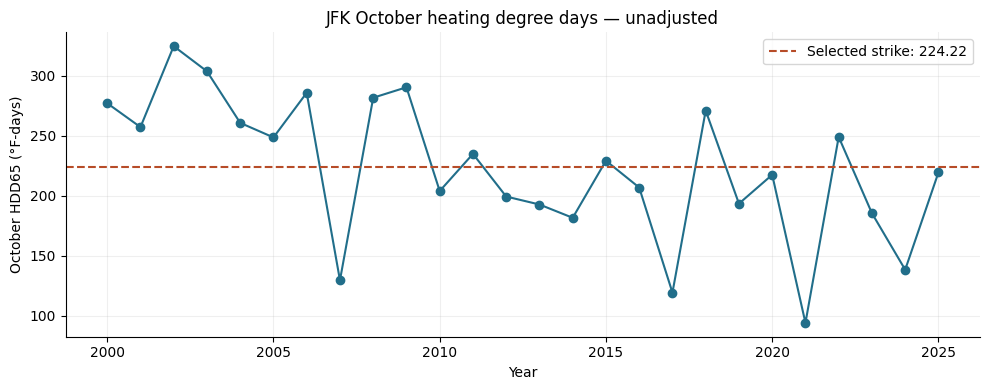

In [3]:
fig, ax = plt.subplots()
ax.plot(yearly.year, yearly.monthly_hdd_f_days, marker="o", color="#216e8a")
ax.axhline(strike, color="#b74c28", linestyle="--", label=f"Selected strike: {strike:.2f}")
ax.set(xlabel="Year", ylabel=index_label, title=f"JFK {month_name} heating degree days — unadjusted")
ax.legend()
fig.tight_layout()
plt.show()

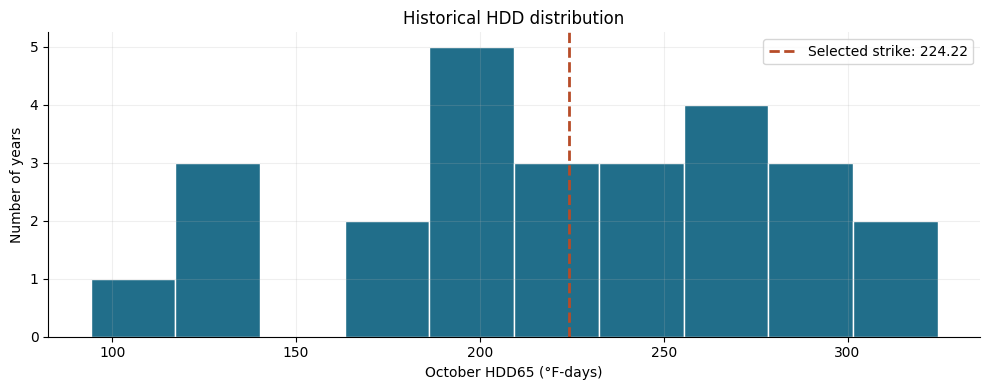

In [4]:
fig, ax = plt.subplots()
ax.hist(valid.monthly_hdd_f_days, bins=min(10, len(valid)), color="#216e8a", edgecolor="white")
ax.axvline(strike, color="#b74c28", linestyle="--", linewidth=2,
           label=f"Selected strike: {strike:.2f}")
ax.set(xlabel=index_label, ylabel="Number of years", title="Historical HDD distribution")
ax.legend()
fig.tight_layout()
plt.show()

## Payoffs in individual historical years

The illustrative median strike is chosen using the full eligible sample and is therefore a descriptive scenario assumption. It is not a historical contract quote or an out-of-sample strategy. The same strike applies to every historical-window comparison.

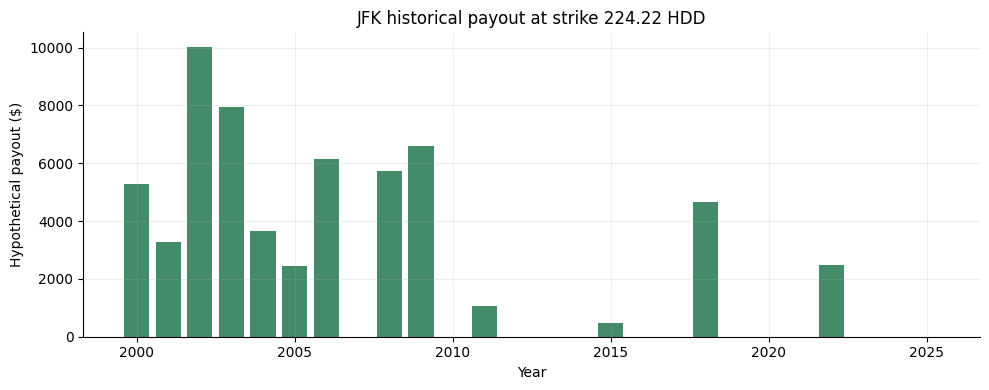

In [5]:
fig, ax = plt.subplots()
ax.bar(valid.year, valid.payout_usd, color="#438b69")
ax.set(xlabel="Year", ylabel="Hypothetical payout ($)", title=f"JFK historical payout at strike {strike:.2f} HDD")
fig.tight_layout()
plt.show()

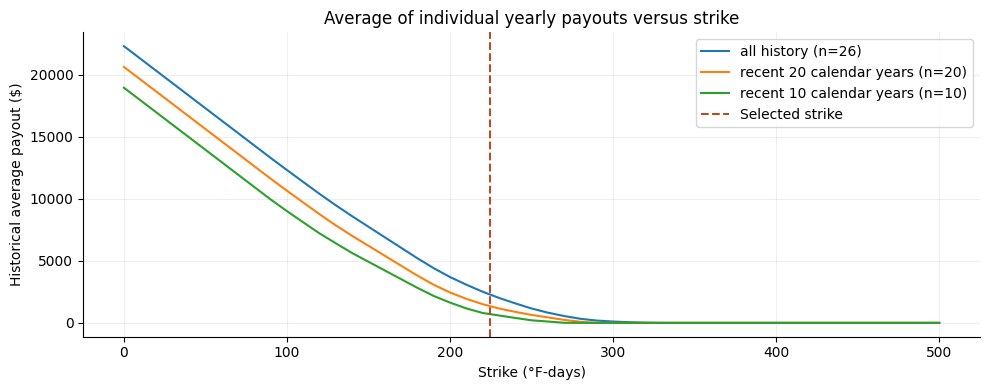

In [6]:
fig, ax = plt.subplots()
for name, group in result["strike_sensitivity"].groupby("window", sort=False):
    ax.plot(group.strike, group.average_payout_usd,
            label=f"{name.replace('_', ' ')} (n={group.actual_valid_years.iloc[0]})")
ax.axvline(strike, color="#b74c28", linestyle="--", label="Selected strike")
ax.set(xlabel="Strike (°F-days)", ylabel="Historical average payout ($)",
       title="Average of individual yearly payouts versus strike")
ax.legend()
fig.tight_layout()
plt.show()

## Historical-window comparison

The recent 20 and 10 **completed calendar years** end in the year before `as_of`: here 2006–2025 and 2016–2025. Counts are the actual valid years in those fixed windows; missing years are never replaced by older years. Full history starts at 2000 (or configured start year) and can include a completed selected month in the current year. Changing the start year can truncate recent-window coverage.

Standard deviation is the sample standard deviation (`ddof=1`); percentiles use linear interpolation. Empty windows have count zero and undefined statistics. A one-year window has undefined sample standard deviation.

In [7]:
display(summary[["window", "first_calendar_year", "last_calendar_year",
                 "effective_start_year", "actual_valid_years", "strike"]].round(2))
hdd_columns = ["hdd_mean", "hdd_median", "hdd_std", "hdd_minimum", "hdd_p10",
               "hdd_p25", "hdd_p75", "hdd_p90", "hdd_maximum"]
display(summary.set_index("window")[hdd_columns].T.round(2))
print(LABEL)
payout_columns = ["payout_mean", "positive_payout_fraction", "payout_median", "payout_p10",
                  "payout_p25", "payout_p75", "payout_p90", "payout_maximum"]
display(summary.set_index("window")[payout_columns].T.round(2))

,window,first_calendar_year,last_calendar_year,effective_start_year,actual_valid_years,strike
0,all_history,2000,2026,2000,26,224.22
1,recent_20_calendar_years,2006,2025,2006,20,224.22
2,recent_10_calendar_years,2016,2025,2016,10,224.22


window,all_history,recent_20_calendar_years,recent_10_calendar_years
hdd_mean,222.83,206.11,189.38
hdd_median,224.22,205.33,200.08
hdd_std,59.13,55.61,56.56
hdd_minimum,94.08,94.08,94.08
hdd_p10,133.96,128.54,116.76
hdd_p25,192.84,184.45,150.12
hdd_p75,268.29,238.33,218.85
hdd_p90,288.00,281.99,251.10
hdd_maximum,324.51,290.28,270.84


historical expected payout before premium, discounting, and risk adjustments


window,all_history,recent_20_calendar_years,recent_10_calendar_years
payout_mean,2298.92,1358.55,713.1
positive_payout_fraction,0.50,0.35,0.2
payout_median,244.50,0.00,0.0
payout_p10,0.00,0.00,0.0
payout_p25,0.00,0.00,0.0
payout_p75,4407.00,1411.50,0.0
payout_p90,6378.00,5777.40,2688.3
payout_maximum,10029.00,6606.00,4662.0


## Excluded years

The table includes the current year's selected month even when it has not yet completed, so its exclusion is visible. No excluded month receives a partial total or a zero payout. Exact missing or invalid dates are saved in `excluded_years.csv`; element-level flags and missing sentinels remain in `quality_audit.csv`.

In [8]:
display(result["excluded_years"][["year", "month", "expected_days", "valid_days",
                                    "month_completed", "exclusion_reason"]])

,year,month,expected_days,valid_days,month_completed,exclusion_reason
26,2026,10,31,0,False,selected month not completed by as_of; 31 miss...


## Interpretation and limits

In this pinned October run, 2000–2025 provides 26 complete years with no historical gaps. October 2026 is not yet completed. HDD has a mean of 222.83 and sample standard deviation of 59.13 °F-days. The illustrative strike is 224.22 HDD and the payout rate is $100 per HDD above that strike. Historical average payouts are $2,298.92 for the full sample, $1,358.55 for 2006–2025 and $713.10 for 2016–2025. These figures describe this parameter set; rerunning with changed parameters updates the tables and plots above.

The recent windows have lower HDD and payout averages in this sample. **Changing climate and station history can affect how representative older observations are.** This initial version makes no climate, station-history or bias adjustments. The short overlapping samples do not establish a trend, forecast probabilities, or quantify uncertainty in future payouts. The maximum shown is an observed historical maximum, not a contractual payout cap.

These are **historical expected payout before premium, discounting, and risk adjustments**. Without a premium, profitability and investment returns cannot be calculated. Live forecasts, bias correction and market pricing remain later stages.